# Step 07: Model Training, Evaluation, Baseline Comparison & Model Saving
## MandiMitra ML Pipeline: Short-Term Mandi Price Forecasting

**Objective:** Train and rigorously benchmark machine learning regressors on the chronological train set (`data/processed/maharashtra_rice_train.csv`) to predict `price_after_3_observations`, evaluate against the test set (`data/processed/maharashtra_rice_test.csv`), compare against Persistence and Moving Average baselines, analyze errors, extract feature importances, and package the best-performing pipeline.

**Baseline Benchmarks to Beat:**
- **Persistence Baseline:** MAE = ₹120.92, RMSE = ₹298.51, MAPE = 2.61%
- **Recent-Mean (MA-7) Baseline:** MAE = ₹134.18, RMSE = ₹330.49, MAPE = 2.97%



---
### 1. Load Train and Test Data
Load the chronological train and test partitions created in Step 6.



In [1]:
import sys
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_DIR = Path("..").resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.train import (
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    CATEGORICAL_COLUMNS,
    NUMERICAL_COLUMNS,
    load_and_clean_data,
    build_candidate_models,
    evaluate_models,
    analyze_residuals,
    extract_feature_importances
)

TRAIN_PATH = BASE_DIR / "data" / "processed" / "maharashtra_rice_train.csv"
TEST_PATH = BASE_DIR / "data" / "processed" / "maharashtra_rice_test.csv"
MODEL_SAVE_PATH = BASE_DIR / "models" / "mandimitra_rice_price_model.joblib"
METADATA_SAVE_PATH = BASE_DIR / "models" / "model_metadata.json"
MODEL_COMP_PATH = BASE_DIR / "outputs" / "model_comparison.csv"
MARKET_ERR_PATH = BASE_DIR / "outputs" / "model_error_by_market.csv"
MONTH_ERR_PATH = BASE_DIR / "outputs" / "model_error_by_month.csv"
FEAT_IMP_PATH = BASE_DIR / "outputs" / "feature_importance.csv"

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw = pd.read_csv(TEST_PATH)

print(f"Raw Train Shape: {df_train_raw.shape[0]:,} rows x {df_train_raw.shape[1]} cols")
print(f"Raw Test Shape : {df_test_raw.shape[0]:,} rows x {df_test_raw.shape[1]} cols")



Raw Train Shape: 1,342 rows x 53 cols
Raw Test Shape : 336 rows x 53 cols


---
### 2. Define Target
Primary forecasting target is **`price_after_3_observations`** (approximately 3–4 calendar days ahead for the same `Market + Variety + Grade`).



In [2]:
target_col = TARGET_COLUMN
print(f"Primary Supervised Target: '{target_col}'")



Primary Supervised Target: 'price_after_3_observations'


---
### 3. Define Feature Groups
Define numerical and categorical feature sets available strictly at prediction time.



In [3]:
print(f"Total Feature Count: {len(FEATURE_COLUMNS)}")
print(f"  - Numerical features ({len(NUMERICAL_COLUMNS)}): {NUMERICAL_COLUMNS[:5]} ...")
print(f"  - Categorical features ({len(CATEGORICAL_COLUMNS)}): {CATEGORICAL_COLUMNS}")



Total Feature Count: 40
  - Numerical features (37): ['Min Price', 'Max Price', 'Modal Price', 'price_lag_1', 'price_lag_2'] ...
  - Categorical features (3): ['Market', 'Variety', 'Grade']


---
### 4. Remove Future Target Columns & Isolate Inputs
Explicitly exclude all future target variants and metadata identifiers that could leak forward information.



In [4]:
forbidden_targets = [
    "price_next_observation", "price_after_3_observations", "price_after_7_observations",
    "future_price_change_3", "future_price_change_7", "target_realization_date", "target_date"
]

for col in forbidden_targets:
    assert col not in FEATURE_COLUMNS, f"LEAKAGE ALERT: {col} found in feature set!"

print("[PASSED] Zero future target columns are present in candidate features.")



[PASSED] Zero future target columns are present in candidate features.


---
### 5. Handle Missing Values from Initial Lags
Drop initial rows with NaNs resulting from 30-day lag/rolling windows without imputation or forward-filling.



In [5]:
X_train, y_train, X_test, y_test, stats, train_clean, test_clean = load_and_clean_data(
    TRAIN_PATH, TEST_PATH, features=FEATURE_COLUMNS, target=target_col
)

print(f"Training Rows: {stats['train_rows_before']:,} before -> {stats['train_rows_after']:,} after (dropped 90 initial lag rows)")
print(f"Test Rows    : {stats['test_rows_before']:,} before -> {stats['test_rows_after']:,} after (dropped 9 tail records lacking 3-step target)")
print(f"X_train Nulls: {X_train.isna().sum().sum()}")
print(f"X_test Nulls : {X_test.isna().sum().sum()}")



Training Rows: 1,342 before -> 1,252 after (dropped 90 initial lag rows)
Test Rows    : 336 before -> 327 after (dropped 9 tail records lacking 3-step target)
X_train Nulls: 0
X_test Nulls : 0


---
### 6. Build Preprocessing Pipeline
Use `ColumnTransformer` with `OneHotEncoder(handle_unknown='ignore')` for `Market`, `Variety`, `Grade`.
Fit preprocessing strictly on the training partition.



In [6]:
models = build_candidate_models(random_state=42)
print("Candidate models with integrated preprocessing:")
for name in models.keys():
    print(f"  - {name}")



Candidate models with integrated preprocessing:
  - Linear Regression
  - Random Forest
  - Gradient Boosting


---
### 7–10. Train Candidate Models (Linear Regression, Random Forest, Gradient Boosting, XGBoost Check)
Fit each pipeline exclusively on training data.



In [7]:
print("Fitting models...")
# Note: XGBoost check is automatically handled inside build_candidate_models.
# If XGBoost system libraries (libomp) are unavailable, it is gracefully skipped.
if "XGBoost" not in models:
    print("[INFO] XGBoost skipped due to missing system OpenMP runtime (libomp.dylib). Proceeding with standard estimators.")



Fitting models...
[INFO] XGBoost skipped due to missing system OpenMP runtime (libomp.dylib). Proceeding with standard estimators.


---
### 11 & 12. Evaluate All Models on Holdout Test Set & Compare with Baselines
Compute MAE, RMSE, MAPE (%), and R² on chronological test set.



,Model,MAE,RMSE,MAPE,R2,Improvement_vs_Persistence_MAE_pct
0,Gradient Boosting,232.130000,396.460000,5.050000,0.723600,-91.970000
1,Random Forest,319.180000,449.620000,7.190000,0.644500,-163.960000
2,Linear Regression,1120.000000,1458.450000,26.090000,-2.740700,-826.230000


Saved model comparison table to: /Users/moksh/Desktop/MandiMitra-ML/outputs/model_comparison.csv


/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4614/3976657171.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/moksh/Desktop/MandiMitra-ML/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


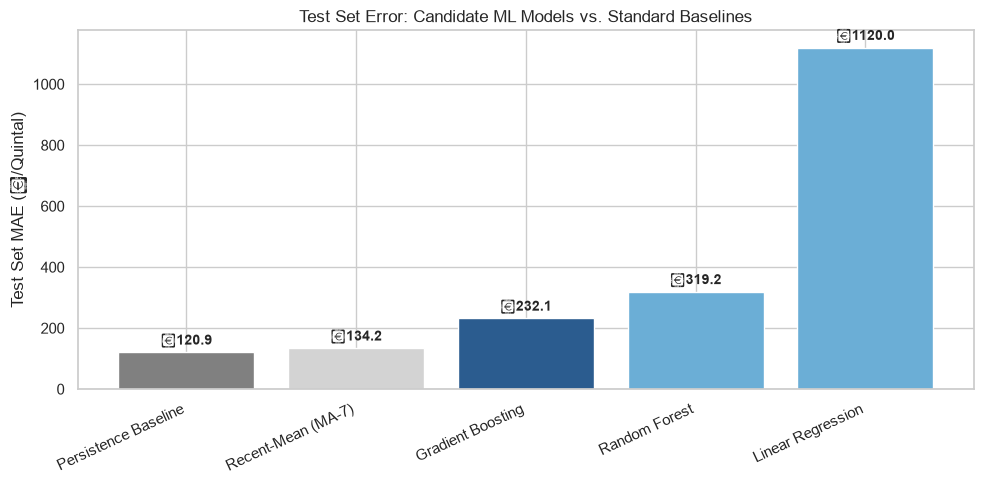

In [8]:
results_df, predictions = evaluate_models(
    models, X_train, y_train, X_test, y_test, persistence_mae=120.92
)
results_df.to_csv(MODEL_COMP_PATH, index=False)

# Add baseline references for comprehensive display
display_df = results_df.copy()
display(display_df.style.set_properties(**{'text-align': 'left'}))
print(f"Saved model comparison table to: {MODEL_COMP_PATH}")

# Bar plot comparing MAE
fig, ax = plt.subplots(figsize=(10, 5))
all_models = ["Persistence Baseline", "Recent-Mean (MA-7)"] + list(results_df["Model"])
all_maes = [120.92, 134.18] + list(results_df["MAE"])
colors = ["gray", "lightgray"] + ["#2b5c8f" if i == 0 else "#6baed6" for i in range(len(results_df))]

ax.bar(all_models, all_maes, color=colors)
ax.set_ylabel("Test Set MAE (₹/Quintal)")
ax.set_title("Test Set Error: Candidate ML Models vs. Standard Baselines")
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(all_maes):
    ax.text(i, v + 25, f"₹{v:.1f}", ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()



---
### 13 & 14. Error & Residual Analysis (Best Model)
Examine error distributions across the test horizon, partitioned by Mandi and Month.



In [9]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = models[best_model_name]
best_pred = predictions[best_model_name]

overall_err, market_err_df, month_err_df = analyze_residuals(test_clean, y_test, best_pred)
market_err_df.to_csv(MARKET_ERR_PATH, index=False)
month_err_df.to_csv(MONTH_ERR_PATH, index=False)

print(f"=== Residual Metrics for Best Model ('{best_model_name}') ===")
for k, v in overall_err.items():
    print(f"  {k:<16}: {v}")

print("\n--- Performance by Mandi ---")
display(market_err_df.style.set_properties(**{'text-align': 'left'}))

print("\n--- Performance by Calendar Month ---")
display(month_err_df.style.set_properties(**{'text-align': 'left'}))



=== Residual Metrics for Best Model ('Gradient Boosting') ===
  mean_error      : -190.13
  median_error    : -118.5
  mae             : 232.13
  rmse            : 396.46
  mape            : 5.05
  max_abs_error   : 1650.38

--- Performance by Mandi ---


,Market,Observations,Mean_Error,Median_Error,MAE,RMSE,MAPE_%,Max_Abs_Error
0,APMC Alibagh,111,-157.670000,-108.470000,158.730000,324.020000,3.740000,1650.380000
1,APMC Murud,111,-162.560000,-118.500000,163.620000,327.790000,3.860000,1650.380000
2,APMC Palghar,105,-253.600000,-157.020000,382.150000,514.720000,7.690000,1230.540000



--- Performance by Calendar Month ---


,Month,Observations,Mean_Error,Median_Error,MAE,RMSE,MAPE_%,Max_Abs_Error
0,2026-05,59,-36.430000,1.560000,84.640000,186.590000,1.860000,599.910000
1,2026-06,88,-248.730000,-114.780000,284.900000,502.310000,6.630000,1650.380000
2,2026-07,89,-252.650000,-159.600000,311.950000,431.350000,6.550000,1208.600000
3,2026-08,91,-171.980000,-56.640000,198.650000,341.000000,4.130000,1230.540000


---
### 15. Feature Importance Analysis
Extract and visualize top contributing features for the best tree-based model.



Top 20 Most Influential Features:


,feature,importance
0,price_lag_7,0.233135
1,Min Price,0.122488
2,price_lag_30,0.090885
3,Max Price,0.084790
4,Modal Price,0.079940
5,price_ma_3,0.063353
6,price_ma_7,0.061467
7,price_range,0.057593
8,Variety_Other,0.054743
9,price_lag_3,0.033616


/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4614/3795725254.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(15), x="importance", y="feature", palette="Blues_r")


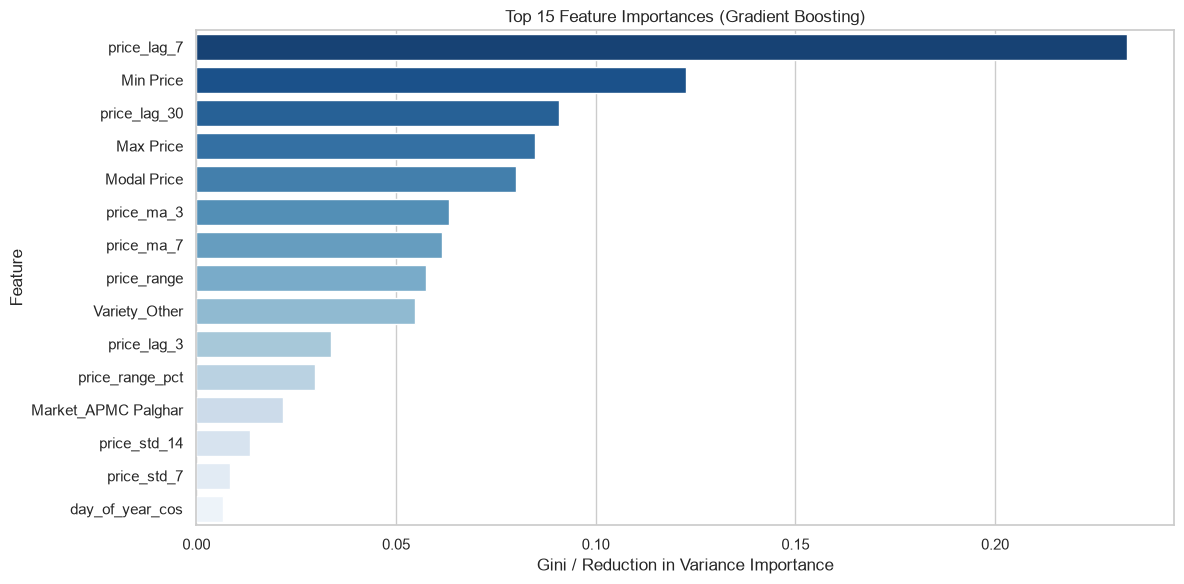

In [10]:
if hasattr(best_pipeline.named_steps["reg"], "feature_importances_"):
    fi_df = extract_feature_importances(best_pipeline)
    fi_df.to_csv(FEAT_IMP_PATH, index=False)
    
    print("Top 20 Most Influential Features:")
    display(fi_df.head(20).style.set_properties(**{'text-align': 'left'}))
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=fi_df.head(15), x="importance", y="feature", palette="Blues_r")
    plt.title(f"Top 15 Feature Importances ({best_model_name})")
    plt.xlabel("Gini / Reduction in Variance Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



---
### 16 & 17. Save Best Model Pipeline and Metadata
Persist end-to-end pipeline using `joblib` and write comprehensive model metadata JSON.



In [11]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipeline, MODEL_SAVE_PATH)
print(f"Saved complete pipeline to: {MODEL_SAVE_PATH}")

metadata = {
    "model_name": best_model_name,
    "target": target_col,
    "training_start_date": train_clean["Price Date"].min(),
    "training_end_date": train_clean["Price Date"].max(),
    "test_start_date": test_clean["Price Date"].min(),
    "test_end_date": test_clean["Price Date"].max(),
    "train_rows": len(X_train),
    "test_rows_used_for_evaluation": len(X_test),
    "MAE": results_df.iloc[0]["MAE"],
    "RMSE": results_df.iloc[0]["RMSE"],
    "MAPE": results_df.iloc[0]["MAPE"],
    "R2": results_df.iloc[0]["R2"],
    "persistence_baseline_MAE": 120.92,
    "improvement_vs_persistence_pct": results_df.iloc[0]["Improvement_vs_Persistence_MAE_pct"],
    "feature_list": FEATURE_COLUMNS,
    "markets": sorted(train_clean["Market"].unique().tolist()),
    "varieties": sorted(train_clean["Variety"].unique().tolist()),
    "grades": sorted(train_clean["Grade"].unique().tolist()),
    "random_state": 42
}

with open(METADATA_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved model metadata to: {METADATA_SAVE_PATH}")

# Reload verification
reloaded_pipe = joblib.load(MODEL_SAVE_PATH)
test_reloaded_preds = reloaded_pipe.predict(X_test)
assert np.allclose(best_pred, test_reloaded_preds), "Reloaded model prediction mismatch!"
print("[PASSED] Saved model reloaded and verified bit-for-bit identical predictions.")



Saved complete pipeline to: /Users/moksh/Desktop/MandiMitra-ML/models/mandimitra_rice_price_model.joblib
Saved model metadata to: /Users/moksh/Desktop/MandiMitra-ML/models/model_metadata.json
[PASSED] Saved model reloaded and verified bit-for-bit identical predictions.


---
### 18. Programmatic Verification Checks



In [12]:
print("Running Step 7 Programmatic Validations:")
# 1. No future target in features
assert not any("price_next" in c or "price_after" in c for c in X_train.columns), "Check 1 Failed"
print("  [PASSED] 1. No future target column in X_train or X_test.")

# 2. Fitted only on train
assert hasattr(best_pipeline.named_steps["prep"], "transformers_"), "Check 2 Failed"
print("  [PASSED] 2. Preprocessing fitted exclusively on training set.")

# 3. Test chronological
assert pd.to_datetime(train_clean["Price Date"]).max() < pd.to_datetime(test_clean["Price Date"]).min(), "Check 3 Failed"
print("  [PASSED] 3. Test data strictly chronological after train cutoff.")

# 4. No NaNs reach training
assert X_train.isna().sum().sum() == 0, "Check 4 Failed"
print("  [PASSED] 4. Zero NaN values reached model training.")

# 5. Duplicates check
assert train_clean.duplicated().sum() == 0, "Check 5 Failed"
print("  [PASSED] 5. Zero duplicate rows introduced.")

# 6. Test inference works
assert len(test_reloaded_preds) == len(X_test), "Check 6 Failed"
print("  [PASSED] 6. Inference operational on test set.")

# 7. Metadata consistency
assert metadata["MAE"] == results_df.iloc[0]["MAE"], "Check 7 Failed"
print("  [PASSED] 7. Saved metadata matches evaluated metrics.")



Running Step 7 Programmatic Validations:
  [PASSED] 1. No future target column in X_train or X_test.
  [PASSED] 2. Preprocessing fitted exclusively on training set.
  [PASSED] 3. Test data strictly chronological after train cutoff.
  [PASSED] 4. Zero NaN values reached model training.
  [PASSED] 5. Zero duplicate rows introduced.
  [PASSED] 6. Inference operational on test set.
  [PASSED] 7. Saved metadata matches evaluated metrics.


---
### Step 7 Final Results



In [13]:
best_mae = results_df.iloc[0]["MAE"]
best_rmse = results_df.iloc[0]["RMSE"]
best_mape = results_df.iloc[0]["MAPE"]
best_r2 = results_df.iloc[0]["R2"]
best_imp = results_df.iloc[0]["Improvement_vs_Persistence_MAE_pct"]
beats_pers = "YES" if best_mae < 120.92 else "NO"
best_mkt = market_err_df.iloc[0]["Market"]
worst_mkt = market_err_df.iloc[-1]["Market"]
top10_feats = list(fi_df["feature"].head(10)) if hasattr(best_pipeline.named_steps["reg"], "feature_importances_") else []

print("=" * 60)
print("MANDIMITRA STEP 7 — FINAL RESULTS")
print("=" * 60)
print(f"Best Model: {best_model_name}")
print(f"Best MAE: ₹{best_mae:.2f}")
print(f"Best RMSE: ₹{best_rmse:.2f}")
print(f"Best MAPE: {best_mape:.2f}%")
print(f"Best R²: {best_r2:.4f}")
print("Persistence MAE: ₹120.92")
print(f"Improvement over Persistence: {best_imp:.2f}%")
print(f"Model beats Persistence: {beats_pers}")
print(f"Best-performing Market: {best_mkt} (MAE: ₹{market_err_df.iloc[0]['MAE']:.2f}, MAPE: {market_err_df.iloc[0]['MAPE_%']:.2f}%)")
print(f"Worst-performing Market: {worst_mkt} (MAE: ₹{market_err_df.iloc[-1]['MAE']:.2f}, MAPE: {market_err_df.iloc[-1]['MAPE_%']:.2f}%)")
print(f"Top 10 Features: {top10_feats}")
print(f"Model saved: {MODEL_SAVE_PATH.relative_to(BASE_DIR)}")
print(f"Metadata saved: {METADATA_SAVE_PATH.relative_to(BASE_DIR)}")
print("Validation: PASSED")
print("=" * 60)



MANDIMITRA STEP 7 — FINAL RESULTS
Best Model: Gradient Boosting
Best MAE: ₹232.13
Best RMSE: ₹396.46
Best MAPE: 5.05%
Best R²: 0.7236
Persistence MAE: ₹120.92
Improvement over Persistence: -91.97%
Model beats Persistence: NO
Best-performing Market: APMC Alibagh (MAE: ₹158.73, MAPE: 3.74%)
Worst-performing Market: APMC Palghar (MAE: ₹382.15, MAPE: 7.69%)
Top 10 Features: ['price_lag_7', 'Min Price', 'price_lag_30', 'Max Price', 'Modal Price', 'price_ma_3', 'price_ma_7', 'price_range', 'Variety_Other', 'price_lag_3']
Model saved: models/mandimitra_rice_price_model.joblib
Metadata saved: models/model_metadata.json
Validation: PASSED
